# TPC-DS Workload Generator Comparison

Reference workload: `tpcds` (the 99 hand-written TPC-DS queries).
Systems under evaluation: any `gpt_generated_*` workload (highlighted); the
remaining generators are shown as muted baselines.

The metrics reported here mirror the CIDR evaluation workbook
(`Evaluation_sheet.xlsx`) so the tables drop straight into the paper:

| Notebook section | Workbook sheet | What it answers |
|---|---|---|
| 1 · Correctness       | §1 Correctness         | Are generated queries valid and runnable? |
| 2 · Schema diversity  | §2 Schema diversity    | Do we touch all schema elements, uniformly? |
| 3 · Structural diversity | §3 Structural diversity | Are the physical plans structurally distinct? |
| 4 · Headline summary  | §6 Backbone ablation (B) | The five headline numbers, side by side. |

Higher is better on every metric below. `tpcds` is the hand-crafted reference,
overlaid for comparison — **not** a target ceiling for the diversity metrics.

In [1]:
import os
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
})

# --- choose one or more result CSVs to combine -------------------------------
# List every file you want in the comparison. Rows are keyed by `workload`;
# if the same workload name appears in more than one file, the LAST file wins,
# so put newer runs later in the list.
CSVS = [
    "results/tpcds_baseline_diversity_comparison_100.csv",
    "results/tpcds_baseline_diversity_comparison_100_v2.1.csv",
    "results/tpcds_baseline_diversity_comparison_100_v3.csv",
]
REF = "tpcds"          # hand-crafted ground-truth workload

# --- load + merge ------------------------------------------------------------
frames = []
for path in CSVS:
    f = pd.read_csv(path)
    f["source_file"] = os.path.basename(path)
    frames.append(f)
df = pd.concat(frames, ignore_index=True)
df = df.drop_duplicates(subset="workload", keep="last").set_index("workload")

# --- classify workloads: reference / ours / baseline -------------------------
OURS      = [w for w in df.index if "gpt_generated" in w and w != REF]
GENS      = [w for w in df.index if w != REF]
BASELINES = [w for w in GENS if w not in OURS]
ORDER     = OURS + BASELINES                    # generators, ours first
ROWS      = [REF] + ORDER                        # reference on top

# --- colours: reference black, ours warm, baselines muted --------------------
_ours_palette = ["#c2410c", "#ea580c", "#f97316", "#fb923c"]
COL = {w: "#b8b8b8" for w in df.index}
for i, w in enumerate(OURS):
    COL[w] = _ours_palette[i % len(_ours_palette)]
COL[REF] = "#111111"

# --- shared table styler -----------------------------------------------------
def show(tbl, fmt="{:.3f}"):
    """Reference row greyed + italic, our workloads highlighted warm."""
    def hl(row):
        if row.name == REF:
            return ["background-color:#f3f4f6;font-style:italic"] * len(row)
        if row.name in OURS:
            return ["background-color:#fff1e6;font-weight:600"] * len(row)
        return [""] * len(row)
    sty = tbl.style.apply(hl, axis=1)
    return sty.format(fmt) if fmt else sty

print(f"{len(df)} workloads loaded from {len(CSVS)} file(s)")
print(f"  reference : {REF}")
print(f"  ours      : {OURS}")
print(f"  baselines : {BASELINES}")
df[["source_file", "query_count"]]

9 workloads loaded from 3 file(s)
  reference : tpcds
  ours      : ['gpt_generated_100_tpcds', 'gpt_generated_100_tpcds_v2.1', 'gpt_generated_100_tpcds_v3']
  baselines : ['bootstrapping_lcm_tpcds', 'e2etune_tpcds', 'sql_factory_tpcds', 'sqlbarber_tpcds', 'sqlstorm_tpcds']


,source_file,query_count
workload,,
tpcds,tpcds_baseline_diversity_comparison_100.csv,99
bootstrapping_lcm_tpcds,tpcds_baseline_diversity_comparison_100.csv,100
e2etune_tpcds,tpcds_baseline_diversity_comparison_100.csv,100
gpt_generated_100_tpcds,tpcds_baseline_diversity_comparison_100.csv,100
sql_factory_tpcds,tpcds_baseline_diversity_comparison_100.csv,100
sqlbarber_tpcds,tpcds_baseline_diversity_comparison_100.csv,100
sqlstorm_tpcds,tpcds_baseline_diversity_comparison_100.csv,100
gpt_generated_100_tpcds_v2.1,tpcds_baseline_diversity_comparison_100_v2.1.csv,100
gpt_generated_100_tpcds_v3,tpcds_baseline_diversity_comparison_100_v3.csv,100


## 1 · Correctness  (workbook §1)

Validity is enforced by prompt-level grounding, not a rewrite loop. `validity %`
= queries that parsed **and** executed / queries requested. Higher is better.

In [2]:
correctness = pd.DataFrame({
    "queries":    df["query_count"],
    "ok":         df["ok"],
    "failed":     df["failed"],
    "validity %": df["ok"] / df["query_count"] * 100,
}).loc[ROWS]

show(correctness, None).format({
    "queries": "{:.0f}", "ok": "{:.0f}", "failed": "{:.0f}", "validity %": "{:.1f}",
})

,queries,ok,failed,validity %
workload,,,,
tpcds,99,99,0,100.0
gpt_generated_100_tpcds,100,100,0,100.0
gpt_generated_100_tpcds_v2.1,100,100,0,100.0
gpt_generated_100_tpcds_v3,100,100,0,100.0
bootstrapping_lcm_tpcds,100,100,0,100.0
e2etune_tpcds,100,100,0,100.0
sql_factory_tpcds,100,100,0,100.0
sqlbarber_tpcds,100,100,0,100.0
sqlstorm_tpcds,100,100,0,100.0


## 2 · Schema diversity  (workbook §2)

*Coverage* — do we touch all schema elements; *usage entropy* — do we use them
uniformly; *unique table-set ratio* — are table combinations varied. All in
`[0, 1]`, higher is better.

In [3]:
SCHEMA = {
    "table_coverage":          "Table cov.",
    "column_coverage":         "Column cov.",
    "join_edge_coverage":      "Join-edge cov.",
    "table_usage_entropy":     "Table entropy",
    "column_usage_entropy":    "Column entropy",
    "join_edge_usage_entropy": "Join-edge entropy",
    "unique_table_set_ratio":  "Unique table-set ratio",
}
schema = df.loc[ROWS, list(SCHEMA)].astype(float).rename(columns=SCHEMA)
show(schema)

,Table cov.,Column cov.,Join-edge cov.,Table entropy,Column entropy,Join-edge entropy,Unique table-set ratio
workload,,,,,,,
tpcds,1.000,0.581,0.683,0.845,0.881,0.824,0.657
gpt_generated_100_tpcds,1.000,0.508,0.951,0.895,0.891,0.896,0.850
gpt_generated_100_tpcds_v2.1,1.000,0.753,0.988,0.992,0.922,0.976,0.990
gpt_generated_100_tpcds_v3,1.000,0.741,0.963,0.991,0.923,0.974,0.990
bootstrapping_lcm_tpcds,1.000,0.593,0.683,0.828,0.868,0.795,0.780
e2etune_tpcds,1.000,0.685,0.951,0.981,0.934,0.959,0.990
sql_factory_tpcds,0.958,0.412,0.329,0.928,0.933,0.918,0.380
sqlbarber_tpcds,0.708,0.202,0.268,0.956,0.966,0.980,0.170
sqlstorm_tpcds,0.917,0.464,0.598,0.839,0.863,0.837,0.710


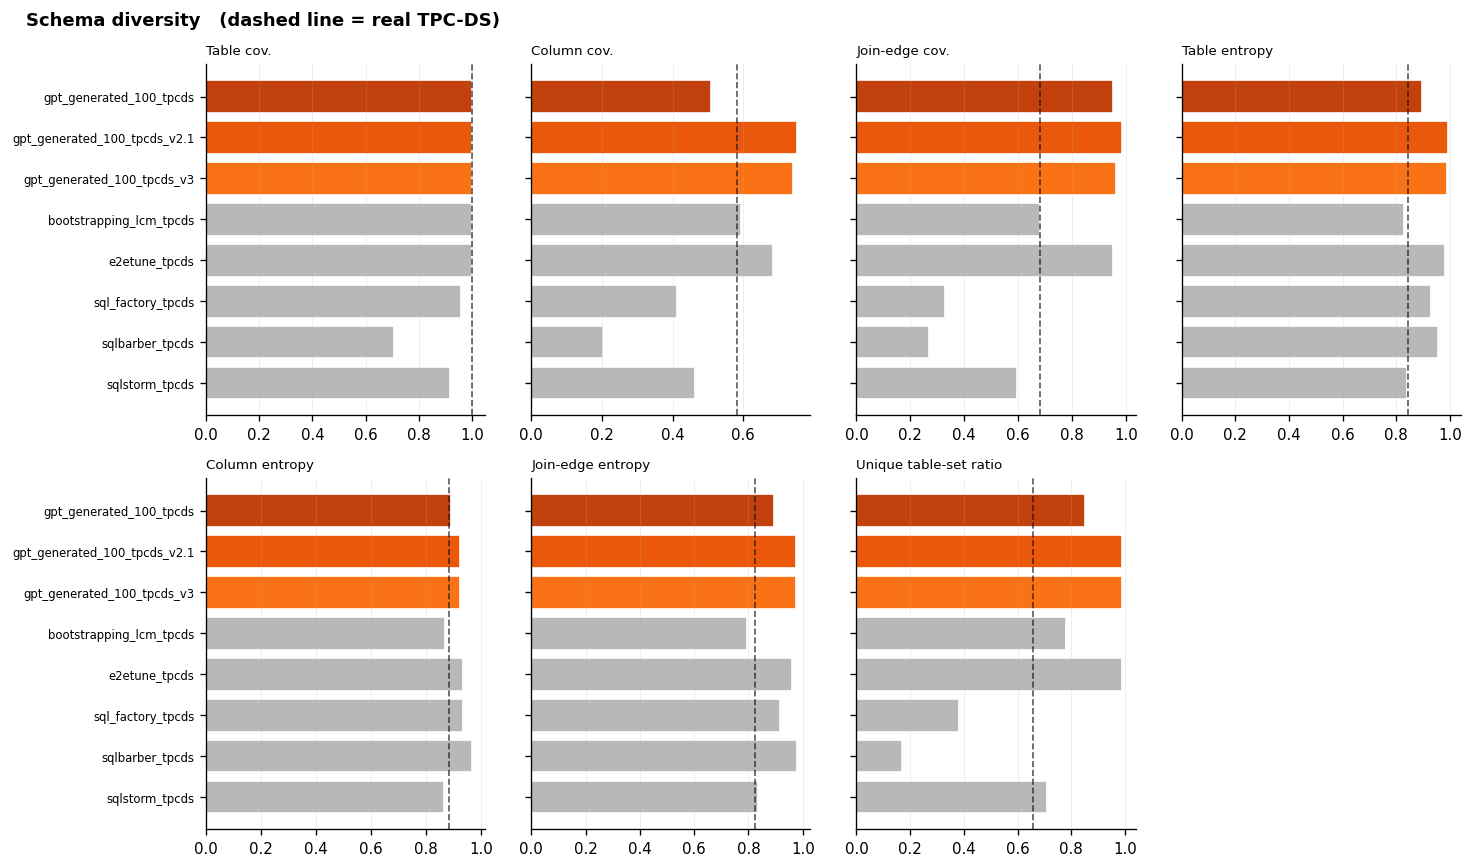

In [4]:
def metric_grid(metrics, title, ncols=4):
    """One horizontal-bar panel per metric; reference drawn as a dashed line."""
    n = len(metrics)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(3.1 * ncols, 0.42 * len(ORDER) * nrows + 0.6))
    axes = np.atleast_1d(axes).ravel()
    for ax, (col, label) in zip(axes, metrics.items()):
        vals = df.loc[ORDER, col].astype(float)
        ax.barh(range(len(ORDER)), vals.values,
                color=[COL[w] for w in ORDER], edgecolor="white")
        ax.axvline(float(df.loc[REF, col]), color=COL[REF], ls="--", lw=1, alpha=.7)
        ax.set_yticks(range(len(ORDER)))
        ax.set_yticklabels(ORDER if ax in (axes[0], axes[ncols]) else [], fontsize=7)
        ax.invert_yaxis()
        ax.set_title(label, fontsize=8, loc="left")
        ax.grid(axis="y", visible=False)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(f"{title}   (dashed line = real TPC-DS)",
                 x=0.02, ha="left", fontweight="bold")
    plt.tight_layout(); plt.show()

metric_grid(SCHEMA, "Schema diversity")

## 3 · Structural diversity  (workbook §3)

Plan-level distinctness from the executed physical plans. *Vendi score* is the
interpretable "effective number" of distinct plans; *mean NN distance* separates
global diversity from a handful of outliers. Higher is better.

In [5]:
STRUCT = {
    "plan_graph_uniqueness_ratio":     "Unique plan-graph ratio",
    "n_operator_types_observed":       "Operator types",
    "operator_type_entropy":           "Operator type entropy",
    "mean_nearest_neighbour_distance": "Mean NN distance",
    "plan_graph_vendi_score":          "Plan-graph Vendi",
}
struct = df.loc[ROWS, list(STRUCT)].astype(float).rename(columns=STRUCT)
show(struct, None).format({
    "Unique plan-graph ratio": "{:.3f}", "Operator types": "{:.0f}",
    "Operator type entropy": "{:.3f}", "Mean NN distance": "{:.3f}",
    "Plan-graph Vendi": "{:.2f}",
})

,Unique plan-graph ratio,Operator types,Operator type entropy,Mean NN distance,Plan-graph Vendi
workload,,,,,
tpcds,0.848,29,0.680,0.243,22.26
gpt_generated_100_tpcds,1.000,25,0.731,0.332,27.19
gpt_generated_100_tpcds_v2.1,0.950,30,0.662,0.292,22.75
gpt_generated_100_tpcds_v3,1.000,28,0.684,0.326,26.26
bootstrapping_lcm_tpcds,0.950,23,0.717,0.206,11.64
e2etune_tpcds,1.000,26,0.756,0.358,26.17
sql_factory_tpcds,0.990,26,0.767,0.303,24.09
sqlbarber_tpcds,0.180,23,0.744,0.000,8.77
sqlstorm_tpcds,0.880,29,0.727,0.372,30.66


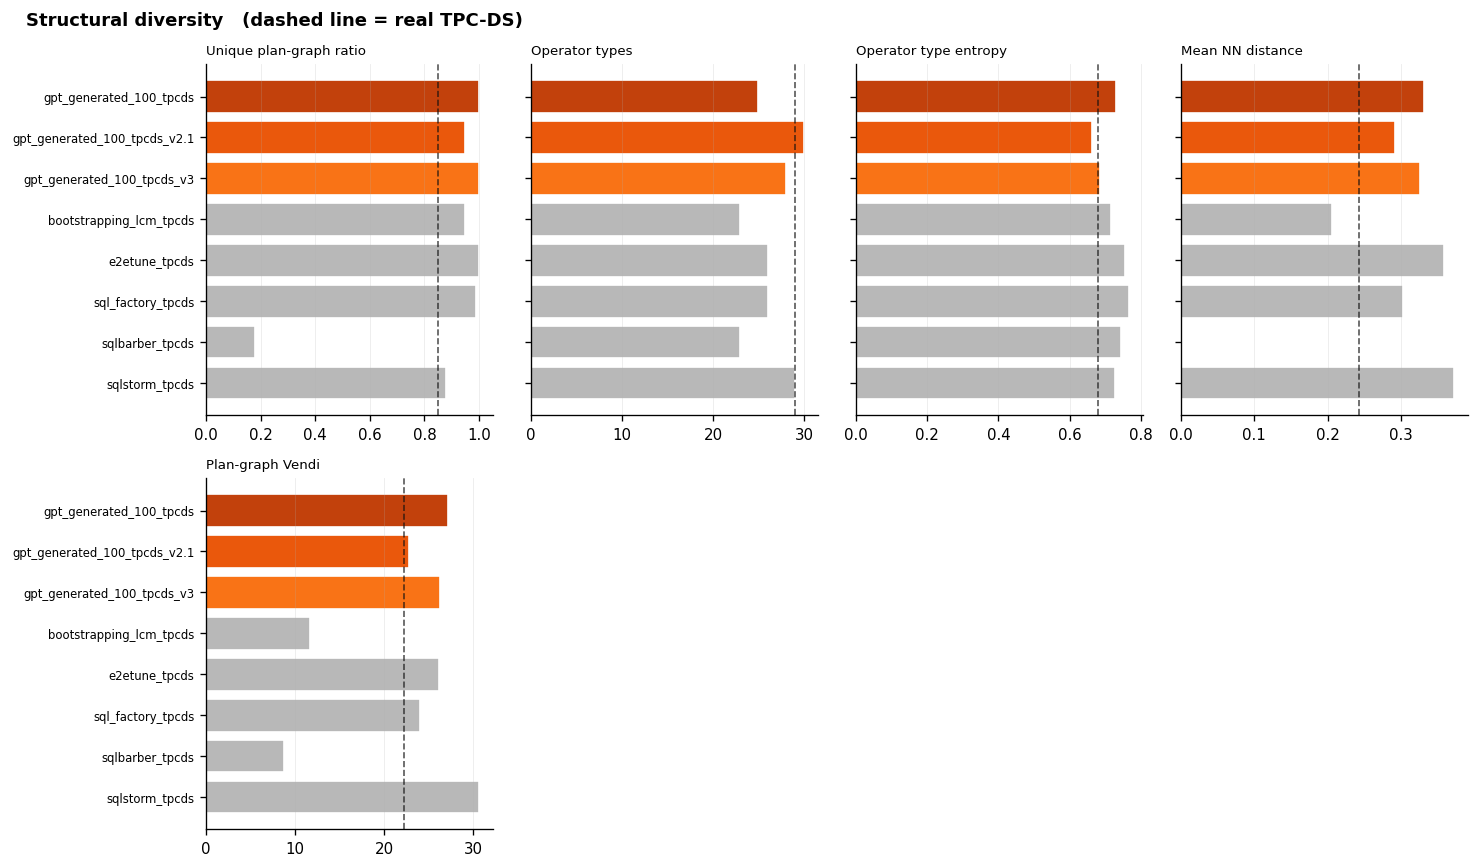

In [6]:
metric_grid(STRUCT, "Structural diversity")

## 4 · Headline summary  (workbook §6B)

The five numbers that go in the ablation / comparison grid: one correctness, two
schema-diversity, two structural-diversity. `tpcds` is the reference row.

In [7]:
headline = pd.DataFrame({
    "validity %":              df["ok"] / df["query_count"] * 100,
    "join-edge cov.":          df["join_edge_coverage"],
    "unique table-set ratio":  df["unique_table_set_ratio"],
    "unique plan-graph ratio": df["plan_graph_uniqueness_ratio"],
    "plan-graph Vendi":        df["plan_graph_vendi_score"],
}).loc[ROWS]

show(headline, None).format({
    "validity %": "{:.1f}", "join-edge cov.": "{:.3f}",
    "unique table-set ratio": "{:.3f}", "unique plan-graph ratio": "{:.3f}",
    "plan-graph Vendi": "{:.2f}",
})

,validity %,join-edge cov.,unique table-set ratio,unique plan-graph ratio,plan-graph Vendi
workload,,,,,
tpcds,100.0,0.683,0.657,0.848,22.26
gpt_generated_100_tpcds,100.0,0.951,0.850,1.000,27.19
gpt_generated_100_tpcds_v2.1,100.0,0.988,0.990,0.950,22.75
gpt_generated_100_tpcds_v3,100.0,0.963,0.990,1.000,26.26
bootstrapping_lcm_tpcds,100.0,0.683,0.780,0.950,11.64
e2etune_tpcds,100.0,0.951,0.990,1.000,26.17
sql_factory_tpcds,100.0,0.329,0.380,0.990,24.09
sqlbarber_tpcds,100.0,0.268,0.170,0.180,8.77
sqlstorm_tpcds,100.0,0.598,0.710,0.880,30.66
